## Summative Lab: Forest Fires Prevention

### Step 1: Load the Dataset

*   Install and import the ucimlrepo library.
*   Load the Forest Fires dataset:
 *   Predictors: Features from forest_fires.data.features.
 *   Target: forest_fires.data.targets.

In [1]:
# Run pip install if necessary to access the UCI ML Repository (uncomment the next line)
# ! pip install ucimlrepo

In [6]:
# Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, classification_report
)

# Load the Forest Fires dataset
url = "https://raw.githubusercontent.com/joanby/python-ml-course/master/datasets/forest-fires/forestfires.csv"
forestfires = pd.read_csv(url)

X = forestfires.drop(columns=['area'])   # Predictors
y = forestfires[['area']]                 # Target

# Display dataset structure
print(X.info())
print(X.describe())
print(y.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), object(2)
memory usage: 48.6+ KB
None
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192 

### Step 2: EDA

* Examine the dataset structure and summary statistics.
* Analyze correlations between predictors and the target variable.
* Plot scatterplots for key predictors vs. the target.
* Generate a residual plot to check for randomness in residuals.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB
None
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900

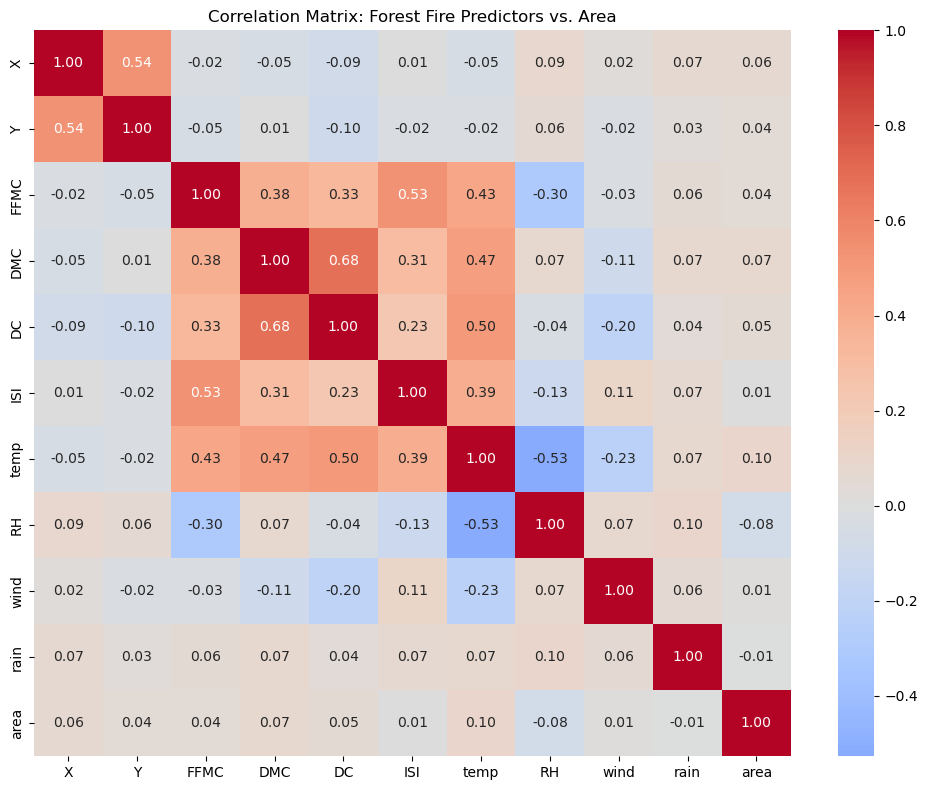

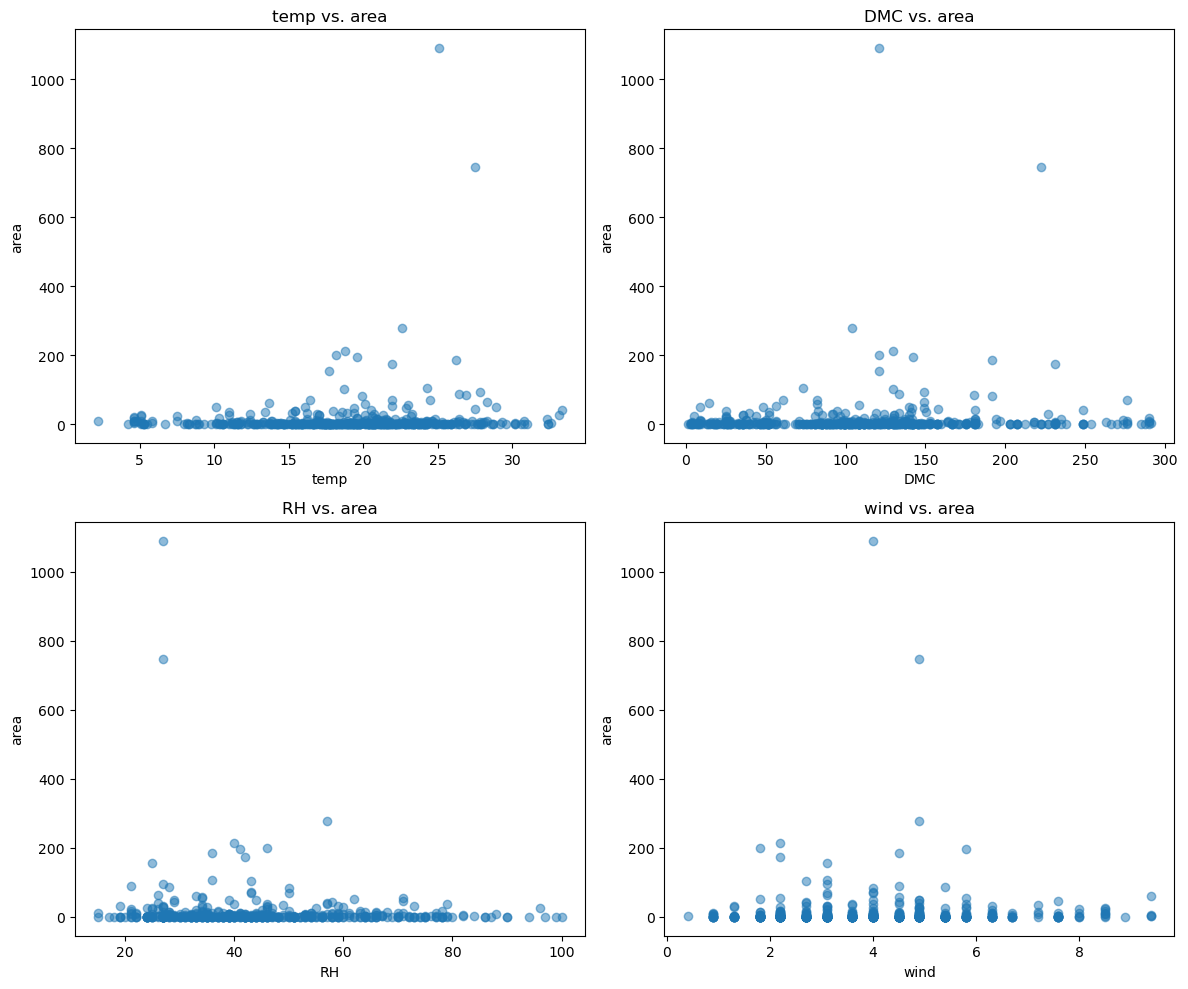

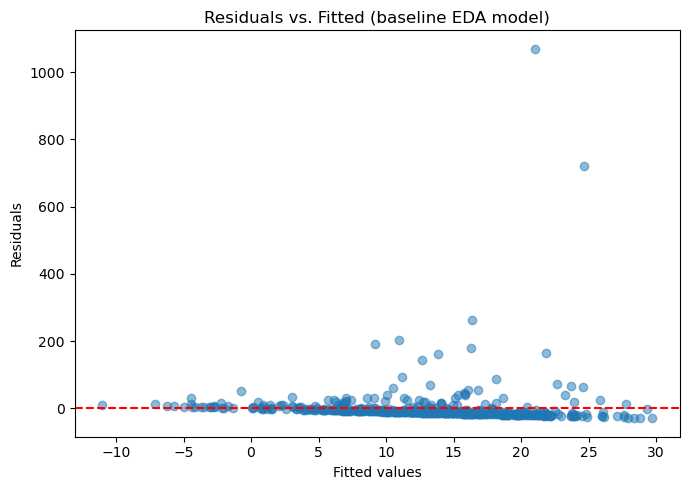

In [7]:

# Combine predictors and target for full-dataset exploration
df = X.copy()
df['area'] = y['area']

# 1. Structure and summary statistics
print(df.info())
print(df.describe())

# 2. Correlations between predictors and area
numeric_cols = ['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain', 'area']
corr_matrix = df[numeric_cols].corr()
print(corr_matrix['area'].sort_values(ascending=False))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix: Forest Fire Predictors vs. Area')
plt.tight_layout()
plt.show()

# 3. Scatterplots for key predictors vs. area
key_predictors = ['temp', 'DMC', 'RH', 'wind']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, col in zip(axes.flatten(), key_predictors):
    ax.scatter(df[col], df['area'], alpha=0.5)
    ax.set_xlabel(col)
    ax.set_ylabel('area')
    ax.set_title(f'{col} vs. area')
plt.tight_layout()
plt.show()

# 4. Baseline residual plot to check for randomness
X_baseline = sm.add_constant(df[['temp', 'RH', 'wind', 'rain']])
baseline_eda_model = sm.OLS(df['area'], X_baseline).fit()

plt.figure(figsize=(7, 5))
plt.scatter(baseline_eda_model.fittedvalues, baseline_eda_model.resid, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted (baseline EDA model)')
plt.tight_layout()
plt.show()

### Step 3: Fit the regression models

* Fit a baseline multiple linear regression model with key predictors.
* Include nonlinear terms (e.g., quadratic transformations for significant predictors).
* Add interaction terms (e.g., between predictors with strong correlations).
* Incorporate indicator variables if categorical variables are present.
* Apply transformations (e.g., logarithmic transformations for skewed predictors).

In [10]:
import statsmodels.formula.api as smf

# Target transformation: log(area + 1) to address the extreme right-skew from Step 2
df['log_area'] = np.log1p(df['area'])


baseline_model = smf.ols('log_area ~ temp + RH + wind + rain + DMC', data=df).fit()
print("Baseline R-squared:", round(baseline_model.rsquared, 4))


df['DMC_squared'] = df['DMC'] ** 2
nonlinear_model = smf.ols('log_area ~ temp + RH + wind + rain + DMC + DMC_squared', data=df).fit()
print("Nonlinear R-squared:", round(nonlinear_model.rsquared, 4))


interaction_model = smf.ols(
    'log_area ~ temp + RH + wind + rain + DMC + DMC_squared + temp:wind',
    data=df
).fit()
print("Interaction R-squared:", round(interaction_model.rsquared, 4))


df['peak_season'] = df['month'].isin(['aug', 'sep']).astype(int)
indicator_model = smf.ols(
    'log_area ~ temp + RH + wind + rain + DMC + DMC_squared + temp:wind + peak_season',
    data=df
).fit()
print("Indicator R-squared:", round(indicator_model.rsquared, 4))


full_model = indicator_model
print(full_model.summary())

Baseline R-squared: 0.0146
Nonlinear R-squared: 0.0148
Interaction R-squared: 0.0246
Indicator R-squared: 0.0247
                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     1.608
Date:                Thu, 24 Sep 2026   Prob (F-statistic):              0.120
Time:                        21:21:28   Log-Likelihood:                -900.00
No. Observations:                 517   AIC:                             1818.
Df Residuals:                     508   BIC:                             1856.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------

### Step 4: Evaluate model diagnostics

* Compare models using metrics like 2R^2, adjusted RR^2, AIC, and BIC.
* Plot residuals and create Q-Q plots to assess normality.
* Identify influential observations using Cook's Distance.

            Model      R2  Adj_R2        AIC        BIC
0        baseline  0.0146  0.0050  1817.3206  1842.8089
1       nonlinear  0.0148  0.0032  1819.2431  1848.9794
2     interaction  0.0246  0.0112  1816.0790  1850.0634
3  indicator/full  0.0247  0.0093  1818.0091  1856.2415


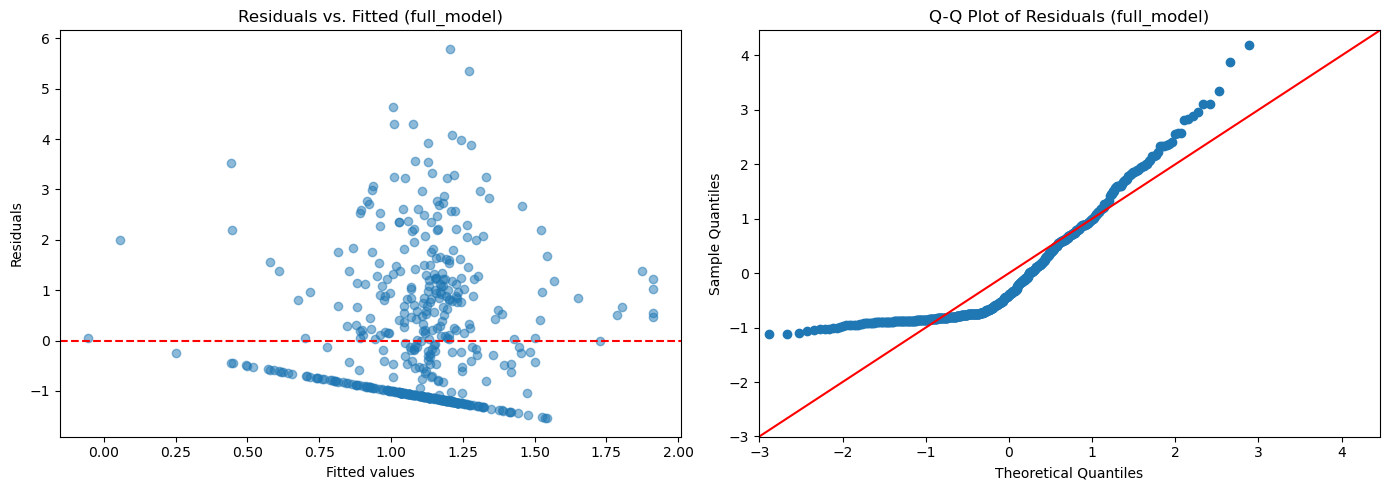

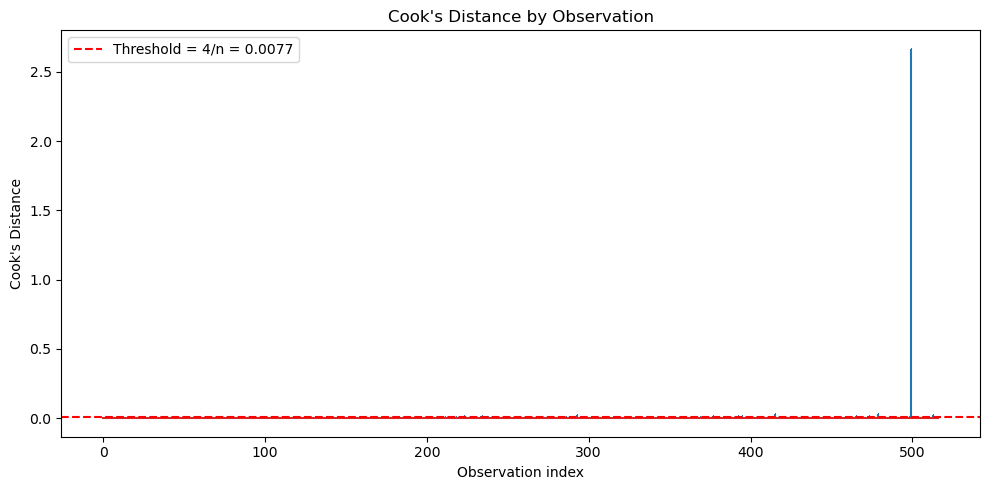

Number of influential observations (Cook's D > 0.0077): 20
       area  log_area  temp  wind  rain    DMC
499   10.82  2.469793  27.3   4.9   6.4  181.1
479  278.53  5.633110  22.6   4.9   0.0  103.9
415  746.28  6.616440  27.5   4.9   0.0  222.4
293   86.45  4.471067  26.9   5.4   0.0  180.4
513   54.29  4.012592  21.9   5.8   0.0   56.7


In [11]:
comparison = pd.DataFrame({
    'Model': ['baseline', 'nonlinear', 'interaction', 'indicator/full'],
    'R2': [baseline_model.rsquared, nonlinear_model.rsquared,
           interaction_model.rsquared, full_model.rsquared],
    'Adj_R2': [baseline_model.rsquared_adj, nonlinear_model.rsquared_adj,
               interaction_model.rsquared_adj, full_model.rsquared_adj],
    'AIC': [baseline_model.aic, nonlinear_model.aic,
            interaction_model.aic, full_model.aic],
    'BIC': [baseline_model.bic, nonlinear_model.bic,
            interaction_model.bic, full_model.bic],
})
print(comparison.round(4))

# 2. Residuals vs. fitted and Q-Q plot for the full model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(full_model.fittedvalues, full_model.resid, alpha=0.5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs. Fitted (full_model)')

sm.qqplot(full_model.resid, line='45', fit=True, ax=axes[1])
axes[1].set_title('Q-Q Plot of Residuals (full_model)')

plt.tight_layout()
plt.show()

# 3. Cook's Distance to identify influential observations
influence = full_model.get_influence()
cooks_d = influence.cooks_distance[0]
threshold = 4 / len(df)  # common rule-of-thumb cutoff

plt.figure(figsize=(10, 5))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
plt.axhline(threshold, color='red', linestyle='--', label=f'Threshold = 4/n = {threshold:.4f}')
plt.xlabel('Observation index')
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance by Observation")
plt.legend()
plt.tight_layout()
plt.show()

influential_obs = df[cooks_d > threshold]
print(f"Number of influential observations (Cook's D > {threshold:.4f}): {len(influential_obs)}")
print(df.loc[np.argsort(cooks_d)[::-1][:5], ['area', 'log_area', 'temp', 'wind', 'rain', 'DMC']])

### Step 5: Apply regularization

* Use Ridge (L2) and Lasso (L1) regression from sklearn to handle multicollinearity.
* Extract coefficients and calculate Mean Squared Error (MSE).
* Compare the performance of Ridge and Lasso models.

In [12]:

df['temp_wind'] = df['temp'] * df['wind']

feature_cols = ['temp', 'RH', 'wind', 'rain', 'DMC', 'DMC_squared', 'temp_wind']
X_reg = df[feature_cols]
y_reg = df['log_area']

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Scale predictors - Ridge/Lasso penalize coefficient magnitude directly, so features on
# very different scales (DMC ranges 1-291; temp ranges 2-33) need to be standardized first
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ridge (L2)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)
ridge_mse = mean_squared_error(y_test, ridge_pred)

# Lasso (L1)
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
lasso_pred = lasso.predict(X_test_scaled)
lasso_mse = mean_squared_error(y_test, lasso_pred)

print("Ridge MSE:", round(ridge_mse, 4))
print("Lasso MSE:", round(lasso_mse, 4))

coef_comparison = pd.DataFrame({
    'Feature': feature_cols,
    'Ridge_coef': ridge.coef_,
    'Lasso_coef': lasso.coef_
})
print(coef_comparison.round(4))

Ridge MSE: 2.2246
Lasso MSE: 2.2034
       Feature  Ridge_coef  Lasso_coef
0         temp      0.3351      0.0000
1           RH     -0.0476     -0.0000
2         wind      0.5265      0.0000
3         rain      0.0483      0.0000
4          DMC      0.2451      0.0294
5  DMC_squared     -0.0865      0.0000
6    temp_wind     -0.5692      0.0000


### Step 6: Prepare the data for binary classification

* Create a binary target variable based on a threshold in y (e.g., median or other percentile).
* Select relevant predictors and scale them using StandardScaler.

In [13]:
threshold = df['area'].median()
df['high_burn'] = (df['area'] > threshold).astype(int)

print("threshold:", threshold)
print(df['high_burn'].value_counts())

# Predictors: the core weather variables used throughout Steps 3-5
clf_features = ['temp', 'RH', 'wind', 'rain', 'DMC']
X_clf = df[clf_features]
y_clf = df['high_burn']

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape, X_test_scaled.shape)

threshold: 0.52
high_burn
0    259
1    258
Name: count, dtype: int64
(361, 5) (156, 5)


### Step 7: Train and evaluate a logistic regression model

Train a logistic regression model using the scaled predictors.

* Display coefficients and the intercept.
* Predict probabilities and binary outcomes.
* Evaluate performance using accuracy, confusion matrix, precision, recall, and F1-score.

In [15]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Coefficients and intercept
print("Intercept:", model.intercept_)
print("Coefficients:")
for feature, coef in zip(clf_features, model.coef_[0]):
    print(f"  {feature}: {round(coef, 4)}")

# Predicted probabilities and binary outcomes
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]
y_pred_class = model.predict(X_test_scaled)

print("First 5 predicted probabilities:", y_pred_prob[:5])
print("First 5 predicted classes:", y_pred_class[:5])

# Performance evaluation
accuracy = accuracy_score(y_test, y_pred_class)
conf_matrix = confusion_matrix(y_test, y_pred_class)
precision = precision_score(y_test, y_pred_class)
recall = recall_score(y_test, y_pred_class)
f1 = f1_score(y_test, y_pred_class)

print("Accuracy:", round(accuracy, 4))
print("Confusion Matrix:\n", conf_matrix)
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

Intercept: [0.00635148]
Coefficients:
  temp: 0.0676
  RH: 0.0699
  wind: 0.1819
  rain: 0.044
  DMC: 0.0794
First 5 predicted probabilities: [0.5292004  0.59914748 0.47680824 0.52253456 0.5474662 ]
First 5 predicted classes: [1 1 0 1 1]
Accuracy: 0.5128
Confusion Matrix:
 [[38 41]
 [35 42]]
Precision: 0.506
Recall: 0.5455
F1-score: 0.525


### Step 8: Check assumptions

* Use Variance Inflation Factor (VIF) to assess multicollinearity among predictors.

In [16]:
vif_data = pd.DataFrame({
    'Feature': clf_features,
    'VIF': [variance_inflation_factor(X_train_scaled, i) for i in range(X_train_scaled.shape[1])]
})
vif_data['VIF'] = vif_data['VIF'].round(3)
print(vif_data)


  Feature    VIF
0    temp  2.336
1      RH  1.887
2    wind  1.054
3    rain  1.041
4     DMC  1.521


### Step 9: Summative Findings

* Compare regression models and classification results.
* Highlight trade-offs between model simplicity, performance, and interpretability.
* Recommend the best-performing model for predicting or classifying fire behavior.

'Regression: there was minimal change across all r^2 our OLS models. The one term that 
was as significant on its own was temp:wind.

'Classification.: A median split of `area` gave a balanced binary target.
Logistic regression oreached 51.3% accuracy / 0.506 precision,
0.546 recall, 0.525 F1 — indistinguishable from chance on a ~50/50 target

'Recommendation There is not added complexity improved results with the more complicated models.

Weather variables alone (temp, RH, wind, rain, DMC) don't reliably predict
fire severity in the dataset.  A more useful model would likely need inputs beyond weather 
ncluding variables such as fuel load, terrain, or suppression
response time.




[Type your findings here.]